# Introduction to Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of analyzing and understanding a dataset before applying any machine learning algorithms or preprocessing techniques.

EDA helps us:
- Understand data structure
- Detect patterns and trends
- Identify missing values
- Detect outliers
- Understand feature distributions
- Make informed preprocessing decisions

In real-world data science workflows, EDA is always performed before model building.

# Why Understanding Data is the First Step in EDA

Before cleaning, transforming, or modeling data, we must understand:
- What type of data we have
- How features are distributed
- Whether data is balanced or skewed
- Presence of anomalies or outliers

If we skip this step, preprocessing and model decisions may become incorrect or biased.

# Loading the Dataset for EDA

We will use a structured dataset (e.g., Iris or Tips dataset) to understand data types and distributions consistently with previous lectures.

In [1]:
# Import required libraries for EDA (pandas, numpy, seaborn, matplotlib)
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (e.g., iris or tips dataset)
iris = sns.load_dataset("iris")
tips = sns.load_dataset("tips")

# Preview the first few rows of the dataset

In [2]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Understanding Dataset Structure

Before analyzing distributions, we must first inspect the dataset structure.
Key questions:
- How many rows and columns exist?
- What are the feature names?
- What are the data types of each column?
- Are there any missing values?

In [ ]:
# Check dataset shape (rows and columns)

# View column names

# Display basic dataset information (data types and non-null counts)

In [4]:
iris.shape

(150, 5)

In [5]:
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [6]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [7]:
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


# Types of Data in Data Analysis

Understanding data types is essential for correct preprocessing and visualization.

Broadly, data is categorized into:
- Numerical Data
- Categorical Data

## Numerical Data (Quantitative Data)

Numerical data consists of values that can be measured and expressed in numbers.

Examples:
- Age
- Salary
- Height
- Temperature
- Total Bill
- Sepal Length (Iris dataset)

Numerical data supports mathematical operations and statistical analysis.

### Types of Numerical Data

1. Continuous Data  
- Can take any value within a range  
- Example: height, weight, temperature  

2. Discrete Data  
- Countable values  
- Example: number of students, number of items, number of transactions

## Categorical Data (Qualitative Data)

Categorical data represents labels or categories instead of numerical measurements.

Examples:
- Gender
- Species (Iris dataset)
- Day (Tips dataset)
- Country
- Product Category

Categorical data is used for grouping and classification tasks.

### Types of Categorical Data

1. Nominal Data  
- No natural order  
- Example: color, gender, country  

2. Ordinal Data  
- Has a meaningful order  
- Example: education level, ratings (low, medium, high)

In [ ]:
# Identify numerical columns in the dataset

# Identify categorical columns in the dataset

# Separate dataset based on data types (numerical vs categorical)

In [8]:
iris_num = iris.select_dtypes(include = ['float64', 'int64'])
iris_num.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
iris_cat = iris.select_dtypes(exclude = ['float64', 'int64'])
iris_cat.head()

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa


In [10]:
tips_num = tips.select_dtypes(include  = ['float64', 'int64'])
tips_num.head()

,total_bill,tip,size
0,16.99,1.01,2
1,10.34,1.66,3
2,21.01,3.50,3
3,23.68,3.31,2
4,24.59,3.61,4


In [11]:
tips_cat = tips.select_dtypes(exclude  = ['float64', 'int64'])
tips_cat.head()

,sex,smoker,day,time
0,Female,No,Sun,Dinner
1,Male,No,Sun,Dinner
2,Male,No,Sun,Dinner
3,Male,No,Sun,Dinner
4,Female,No,Sun,Dinner


#  Understanding Data Distribution

Data distribution describes how values are spread across a dataset.
It helps us understand:
- Central tendency
- Spread of data
- Skewness
- Presence of outliers
- Normal vs non-normal behavior

## Why Distribution Analysis is Important

Understanding distribution helps in:
- Choosing appropriate preprocessing techniques
- Detecting skewed features
- Identifying outliers
- Feature transformation decisions (log, scaling, etc.)
- Improving model performance

# Histogram – Distribution Visualization

A Histogram shows how frequently data values occur within specific ranges (bins).
It is one of the most fundamental plots used in EDA to analyze numerical distributions.

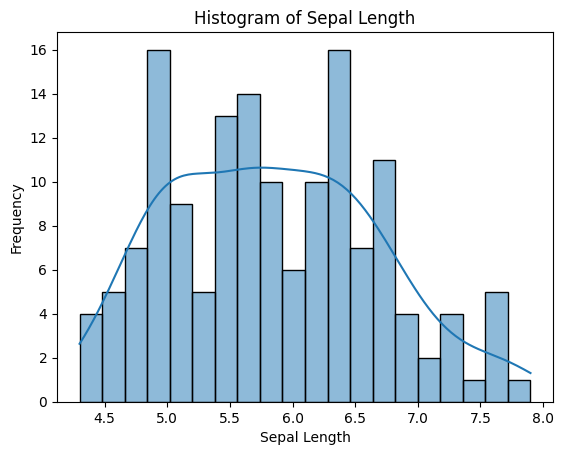

In [13]:
# Create figure and axes using plt.subplots()
# Select a numerical column for distribution analysis
# Plot histogram to visualize frequency distribution
# Add title and axis labels
# Display the plot

fig, ax = plt.subplots()
sns.histplot(
    data = iris,
    x="sepal_length",
    bins=20,
    ax=ax,
    kde = True
)
ax.set_title("Histogram of Sepal Length")
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Frequency")

plt.show()

# KDE Plot – Smooth Distribution Analysis

Kernel Density Estimation (KDE) provides a smooth curve representing the probability density of a feature.
It helps in understanding the shape of the distribution more clearly than histograms.

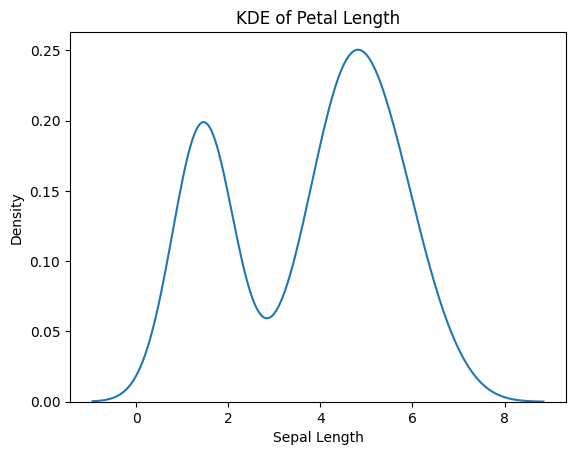

In [16]:
# Create figure and axes

# Select a numerical feature for density analysis

# Plot KDE curve for distribution understanding

# Add title and labels for interpretation

# Show the visualization

fig, ax = plt.subplots()
sns.kdeplot(
    data = iris,
    x="petal_length",
    ax=ax,
)
ax.set_title("KDE of Petal Length")
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Density")

plt.show()

# Boxplot for Distribution & Outlier Detection

Boxplots summarize data distribution using:
- Median
- Quartiles (Q1, Q3)
- Interquartile Range (IQR)
- Outliers

This makes them extremely useful in EDA for detecting anomalies.

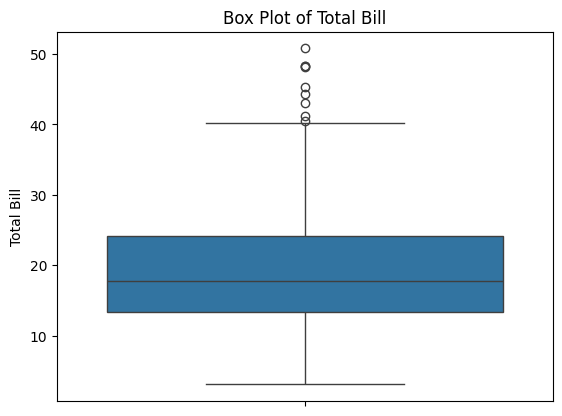

In [17]:
# Create figure and axes using plt.subplots()
# Select numerical feature for y-axis
# Create a boxplot to analyze spread and outliers
# Add title and axis labels
# Display the plot

fig, ax = plt.subplots()

sns.boxplot(
    data = tips,
    y="total_bill",
    ax=ax
)
ax.set_title("Box Plot of Total Bill")
ax.set_ylabel("Total Bill")

plt.show()

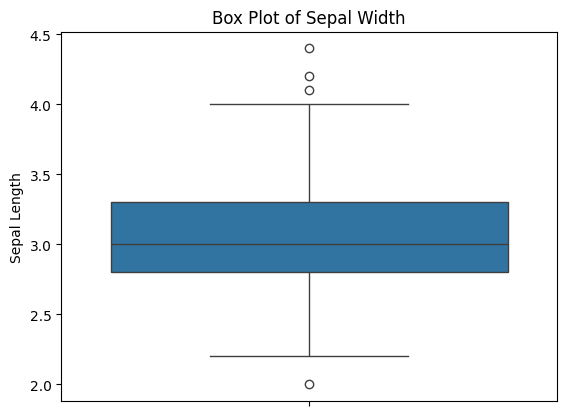

In [21]:
fig, ax = plt.subplots()

sns.boxplot(
    data = iris,
    y="sepal_width",
    ax=ax
)
ax.set_title("Box Plot of Sepal Width")
ax.set_ylabel("Sepal Length")

plt.show()

# Distribution of Categorical Data

For categorical features, distribution means frequency of each category.
This helps in understanding:
- Class balance
- Dominant categories
- Data composition

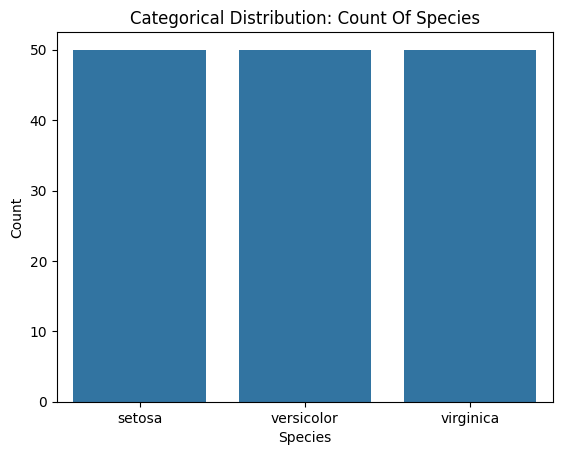

In [22]:
# Create figure and axes
# Select categorical column for analysis
# Plot count plot to visualize category frequency
# Add labels and title
# Show the visualization
fig, ax = plt.subplots()
sns.countplot(
    data = iris,
    x='species',
    ax =ax
)
ax.set_title("Categorical Distribution: Count Of Species")
ax.set_xlabel("Species")
ax.set_ylabel("Count")

plt.show()

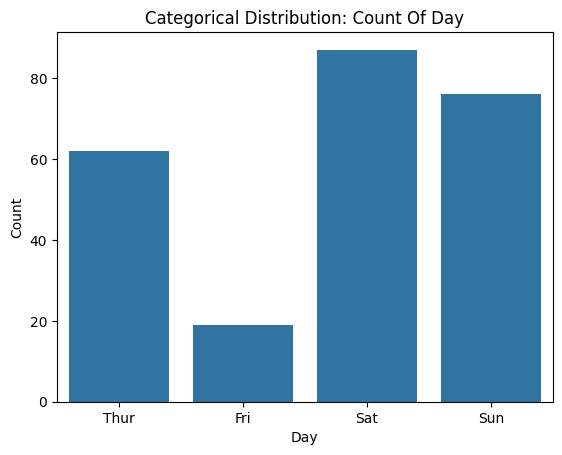

In [23]:
fig, ax = plt.subplots()
sns.countplot(
    data = tips,
    x='day',
    ax =ax
)
ax.set_title("Categorical Distribution: Count Of Day")
ax.set_xlabel("Day")
ax.set_ylabel("Count")

plt.show()

In [25]:
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


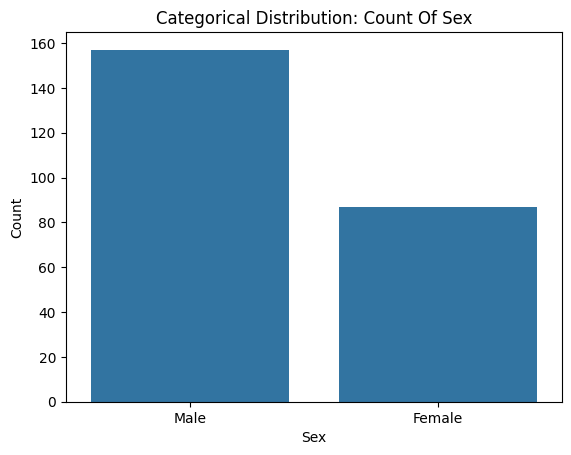

In [26]:
fig, ax = plt.subplots()
sns.countplot(
    data = tips,
    x='sex',
    ax =ax
)
ax.set_title("Categorical Distribution: Count Of Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Count")

plt.show()

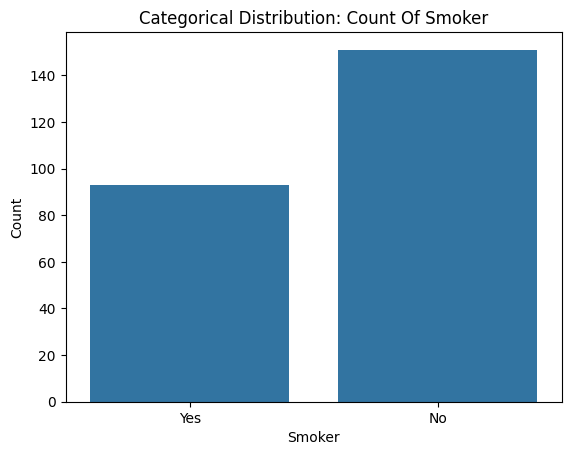

In [27]:
fig, ax = plt.subplots()
sns.countplot(
    data = tips,
    x='smoker',
    ax =ax
)
ax.set_title("Categorical Distribution: Count Of Smoker")
ax.set_xlabel("Smoker")
ax.set_ylabel("Count")

plt.show()

In [ ]:
# Create figure and axes

# Select a categorical column from the dataset

# Plot count plot for category frequency distribution

# Add labels and title for clarity

# Show the plot

# Skewness in Data Distribution (Asymmetrical Distribution)

Skewness indicates asymmetry in data distribution.

Types:
- Positive Skew (Right Skew) → Long right tail
- Negative Skew (Left Skew) → Long left tail
- Normal Distribution → Symmetrical distribution

### Positive Skew (Right-Skewed Distribution)

Characteristics:
- Long tail on the right side
- Mean > Median
- Majority of values concentrated on the left

Example:
Income distribution, transaction amounts

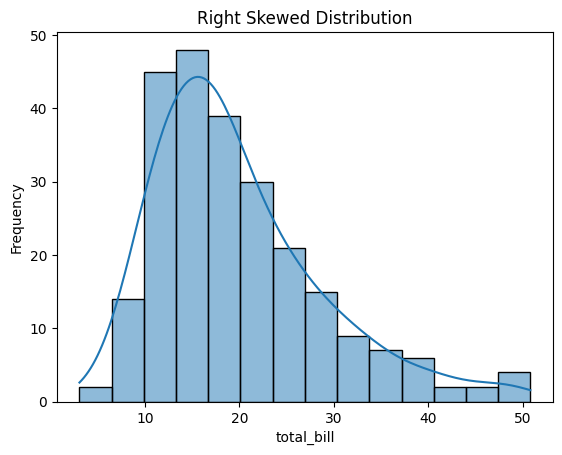

In [28]:
# Create figure and axes
# Select a right-skewed numerical feature
# Plot histogram to observe long right tail
# Add KDE curve to understand skewness clearly
# Add proper labels and title
# Show the plot

fig, ax = plt.subplots()
sns.histplot(
    data =  tips,
    x ="total_bill",
    kde= True,
    ax = ax
)

ax.set_title("Right Skewed Distribution")
ax.set_xlabel("total_bill")
ax.set_ylabel("Frequency")

plt.show()

### Negative Skew (Left-Skewed Distribution)

Characteristics:
- Long tail on the left side
- Mean < Median
- Majority of values concentrated on the right

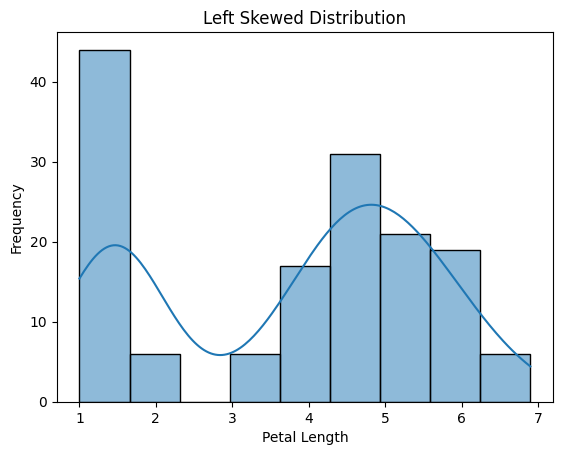

In [34]:
# Create figure and axes
# Select a feature that may show left skewness
# Plot histogram with density curve
# Analyze tail direction visually
# Display the visalization

fig, ax = plt.subplots()
sns.histplot(
    data =  iris,
    x ="petal_length",
    kde= True,
    ax = ax
)

ax.set_title("Left Skewed Distribution")
ax.set_xlabel("Petal Length")
ax.set_ylabel("Frequency")

plt.show()

# Normal Distribution (Gaussian Distribution)

## Concept

A Normal Distribution is a symmetrical, bell-shaped distribution where:
- Mean ≈ Median ≈ Mode
- Most values cluster around the center
- Tails decrease evenly on both sides

This is the most important distribution in statistics and machine learning.

### Key Characteristics:
- Symmetrical shape
- No skewness
- Predictable statistical behavior
- Common in natural and measurement data (height, weight, exam scores)

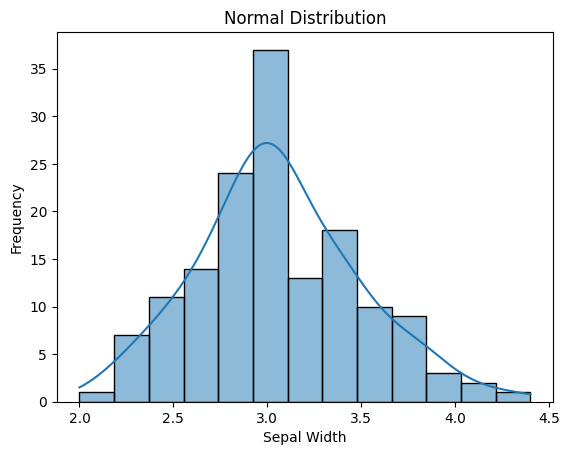

In [35]:
# Create figure and axes using plt.subplots()
# Select a numerical feature that appears normally distributed
# Plot histogram to observe bell-shaped distribution
# Optionally overlay KDE curve for smooth distribution view
# Add title and axis labels
# Display the visualization

fig, ax = plt.subplots()
sns.histplot(
    data =  iris,
    x ="sepal_width",
    kde= True,
    ax = ax
)

ax.set_title("Normal Distribution")
ax.set_xlabel("Sepal Width")
ax.set_ylabel("Frequency")

plt.show()

# Uniform Distribution

## Concept

In a Uniform Distribution, all values occur with approximately equal frequency.
There is no central peak, and data is evenly spread across the range.

Characteristics:
- Flat distribution shape
- No skewness
- Equal probability across values

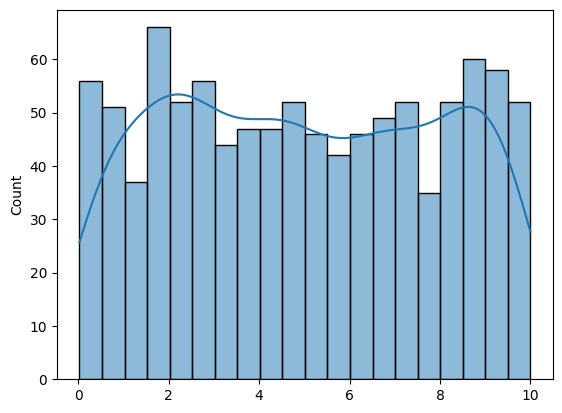

In [43]:
# Create figure and axes
# Select a feature (or simulated evenly spread data)
# Plot histogram to observe flat distribution pattern
# Add labels and title for interpretation
# Display the plot

uniform_data = np.random.uniform(low =0, high = 10, size=1000)
fig,ax = plt.subplots()

sns.histplot(
    uniform_data,
    bins = 20,
    ax =ax,
    kde = True
)

plt.show()

# Bimodal Distribution (Multiple Peaks)

## Concept

A Bimodal Distribution contains two distinct peaks (modes) in the data.
This often indicates:
- Presence of subgroups in data
- Mixed populations
- Hidden clusters within a dataset

### Real-World Example:
Customer spending patterns:
- Low spenders group
- High spenders group

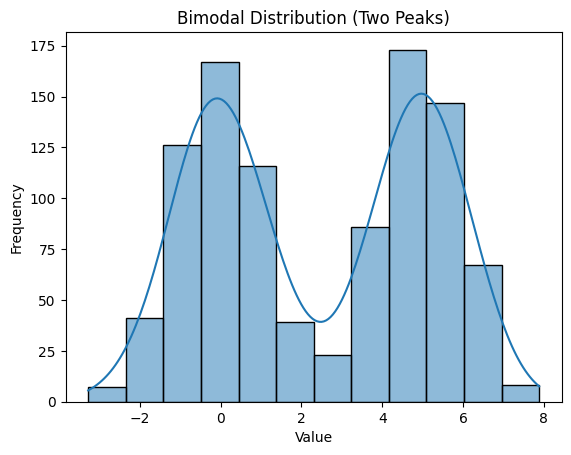

In [49]:
# Create figure and axes
# Select a feature that may contain multiple clusters
# Plot histogram with KDE curve
# Observe presence of two peaks in distribution
# Add title and axis labels
# Show the visualization

data1 = np.random.normal(0, 1, 500)

data2 = np.random.normal(5, 1, 500)

bimodal_data = np.concatenate([data1, data2])

fig, ax = plt.subplots()
sns.histplot(bimodal_data, kde=True, ax=ax)

ax.set_title("Bimodal Distribution (Two Peaks)")
ax.set_xlabel("Value")
ax.set_ylabel("Frequency")

plt.show()

# Comparing Multiple Distributions (Feature-wise Analysis)

In EDA, we often compare distributions of multiple numerical features to understand:
- Scale differences
- Variability
- Skewness differences
- Feature behavior

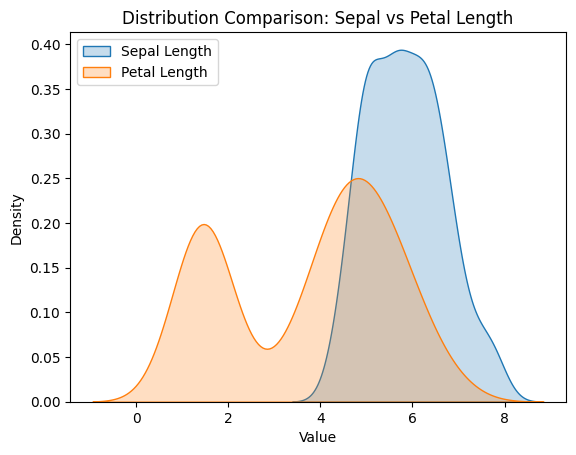

In [50]:
# Create figure and axes

# Select multiple numerical features for comparison

# Plot distribution plots (histogram/KDE) for each feature

# Add legend and titles for interpretation

# Display the visualization

fig, ax = plt.subplots()
sns.kdeplot(data=iris, x="sepal_length", label="Sepal Length", fill=True)
sns.kdeplot(data=iris, x="petal_length", label="Petal Length", fill=True)

ax.set_title("Distribution Comparison: Sepal vs Petal Length")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.legend()

plt.show()

In [51]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [52]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000
